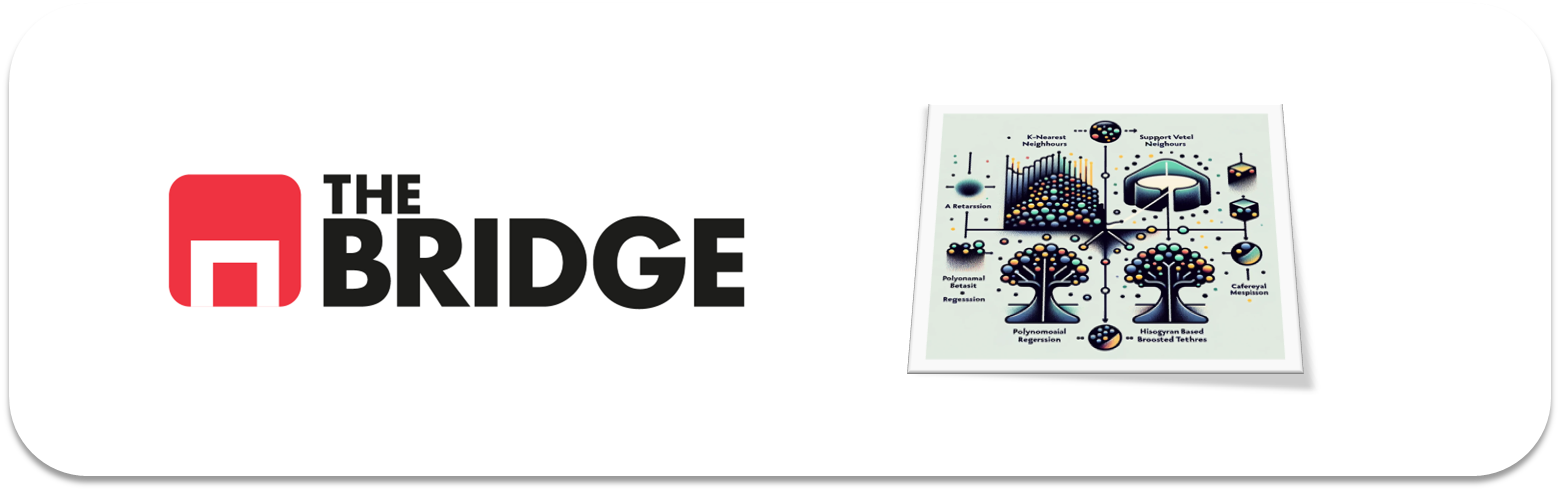

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [226]:
import bootcampviztools as bt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
 
from imblearn.over_sampling import SMOTE # Nuevos amigos para ayudaros
from imblearn.under_sampling import RandomUnderSampler # Nuevos amigos para ayudarnos
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [227]:
df = pd.read_csv("./data/credit_npo.csv")

In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [229]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


 0   SeriousDlqin2yrs : probabilidad de quiebra en 2 años

 1   RevolvingUtilizationOfUnsecuredLines : Uso de crédito no garantizado

 2   age : edad

 3   NumberOfTime30-59DaysPastDueNotWorse : Número de veces que el cliente se retrasó entre 30 y 59 días  

 4   DebtRatio : ratio de deuda                     

 5   MonthlyIncome : ingresos mensuales            

 6   NumberOfOpenCreditLinesAndLoans  : número de créditos y préstamos abiertos    

 7   NumberOfTimes90DaysLate : numero de veces que se retrasó más de 90 días en un pago

 8   NumberRealEstateLoansOrLines : Número de préstamos o líneas asociadas a bienes raíces
 
 9   NumberOfTime60-89DaysPastDueNotWorse : Retrasos de 60 a 89 días


In [230]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [231]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [232]:
numericas = ['RevolvingUtilizationOfUnsecuredLines', 'age',
        'DebtRatio', 'MonthlyIncome'
       ]

In [233]:
categoricas = ['NumberOfTime30-59DaysPastDueNotWorse','NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents']

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

In [234]:
target = "SeriousDlqin2yrs"

es un problema de clasificación

### #1.3
Pinta la distribución de frecuencias del target y coméntala

<Axes: xlabel='SeriousDlqin2yrs', ylabel='Count'>

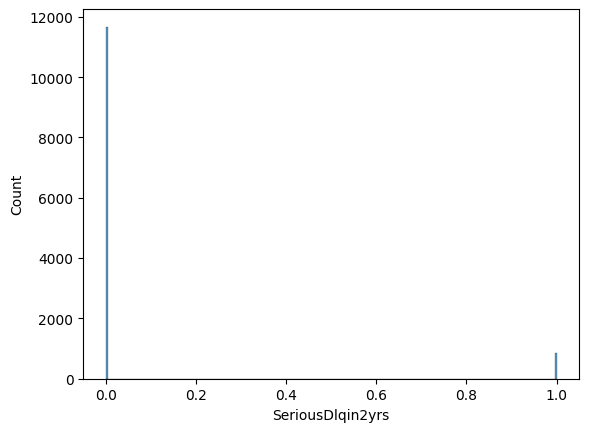

In [235]:
sns.histplot(df[target])

In [236]:
df[target].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.931084
1    0.068916
Name: proportion, dtype: float64

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [237]:
df_train, df_test = train_test_split(df, train_size=0.8, random_state=42)

In [238]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10029 entries, 5441 to 7270
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      10029 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  10029 non-null  float64
 2   age                                   10029 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  10029 non-null  int64  
 4   DebtRatio                             10029 non-null  float64
 5   MonthlyIncome                         9458 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       10029 non-null  int64  
 7   NumberOfTimes90DaysLate               10029 non-null  int64  
 8   NumberRealEstateLoansOrLines          10029 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  10029 non-null  int64  
 10  NumberOfDependents                    9889 non-null   float64
dtypes: float64(4), int

In [239]:
df_train["MonthlyIncome_binary"] = df_train["MonthlyIncome"]!=0
df_train["NumberOfDependents_binary"] = df_train["NumberOfDependents"]!=0

In [240]:
df_train["MonthlyIncome"] = (df_train["MonthlyIncome"].fillna(df_train.groupby("age")["MonthlyIncome"].transform("median")))

In [241]:
df_train["NumberOfDependents"] = (df_train["NumberOfDependents"].fillna(df_train.groupby("age")["NumberOfDependents"].transform("median")))

In [242]:
df_test["MonthlyIncome_binary"] = df_test["MonthlyIncome"]!=0
df_test["NumberOfDependents_binary"] = df_test["NumberOfDependents"]!=0
df_test["MonthlyIncome"] = (df_test["MonthlyIncome"].fillna(df_test.groupby("age")["MonthlyIncome"].transform("median")))
df_test["NumberOfDependents"] = (df_test["NumberOfDependents"].fillna(df_test.groupby("age")["NumberOfDependents"].transform("median")))

In [243]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2508 entries, 9525 to 7995
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      2508 non-null   int64  
 1   RevolvingUtilizationOfUnsecuredLines  2508 non-null   float64
 2   age                                   2508 non-null   int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  2508 non-null   int64  
 4   DebtRatio                             2508 non-null   float64
 5   MonthlyIncome                         2508 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       2508 non-null   int64  
 7   NumberOfTimes90DaysLate               2508 non-null   int64  
 8   NumberRealEstateLoansOrLines          2508 non-null   int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  2508 non-null   int64  
 10  NumberOfDependents                    2508 non-null   float64
 11  MonthlyIncome_binar

In [244]:
binarias = ["MonthlyIncome_binary","NumberOfDependents_binary"] 

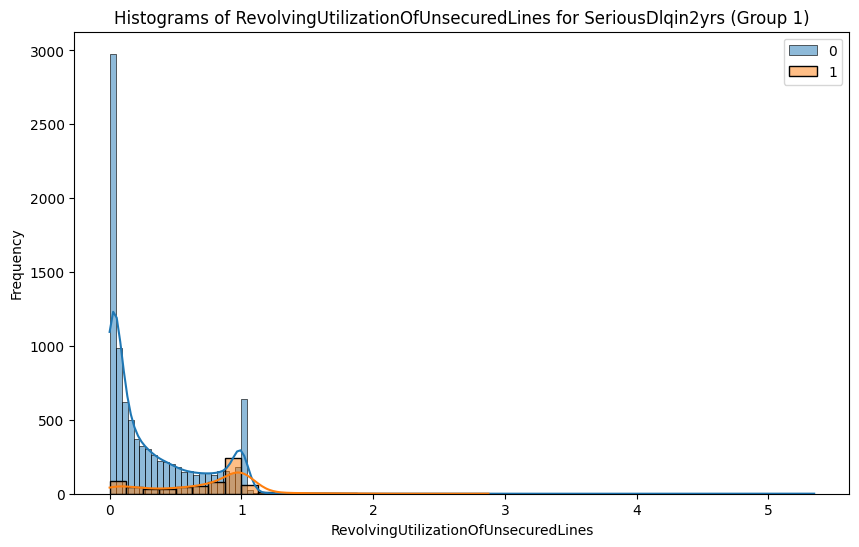

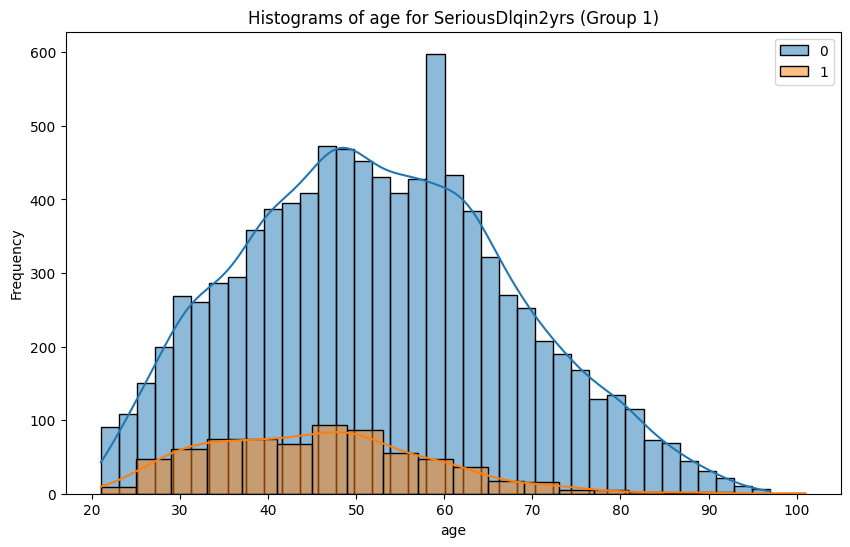

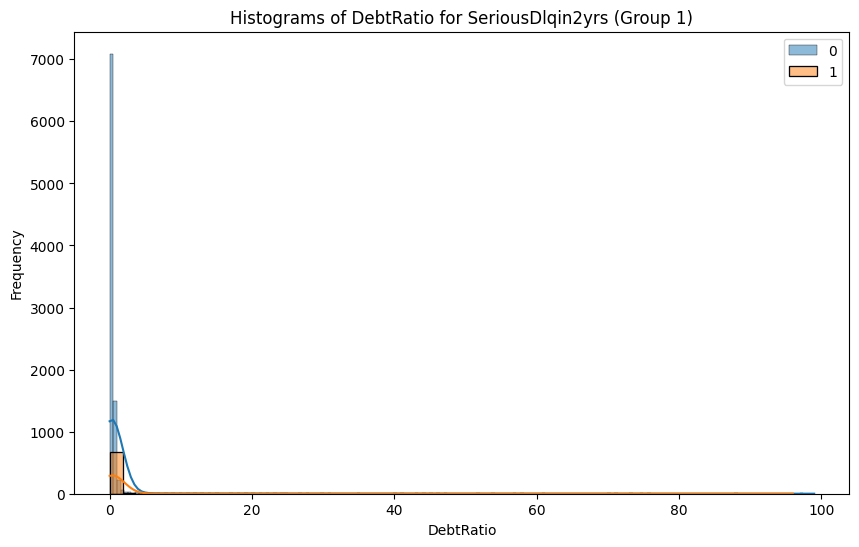

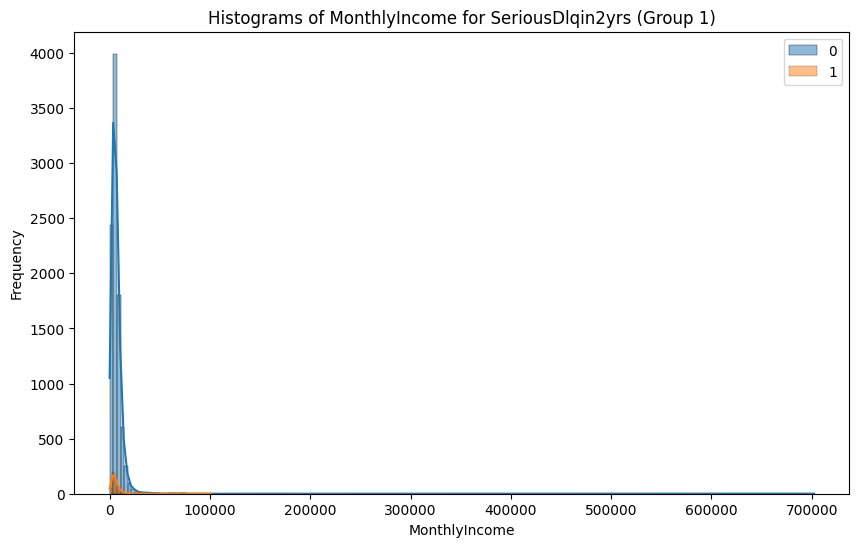

In [245]:
for numerica in numericas:
    bt.plot_grouped_histograms(df_train, target, numerica, len(numericas) )

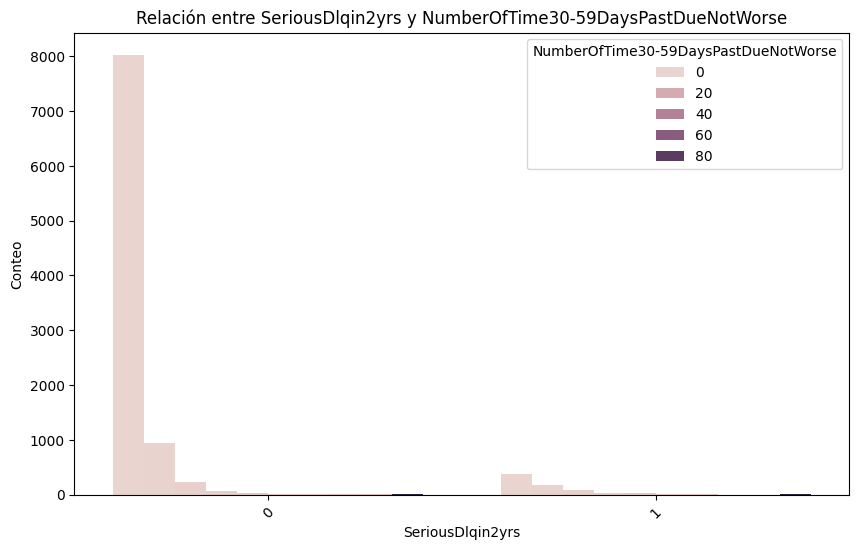

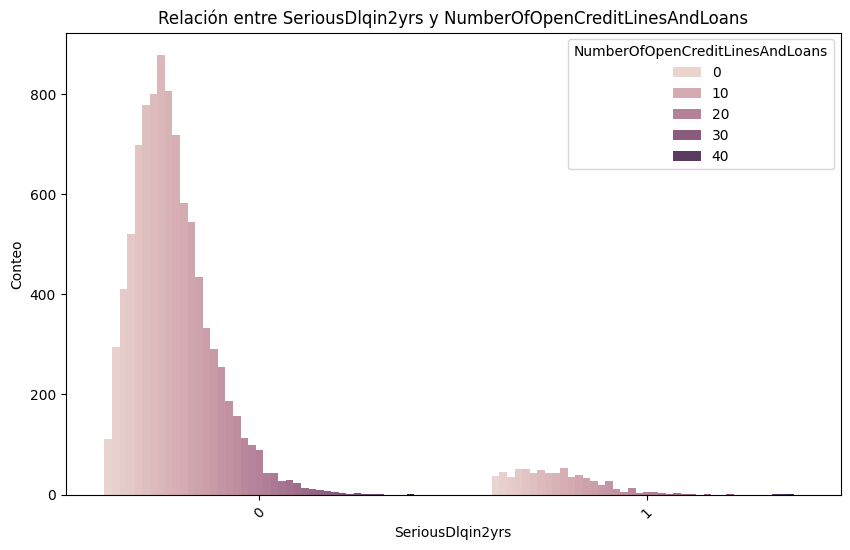

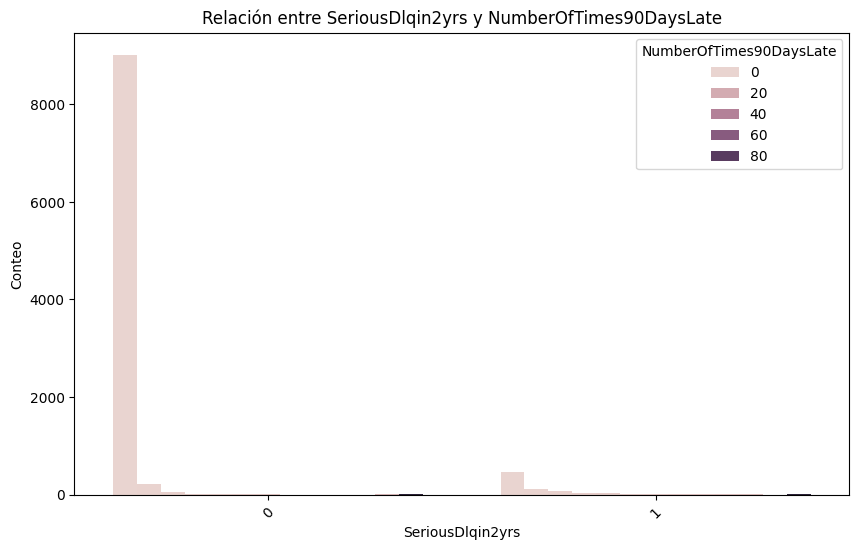

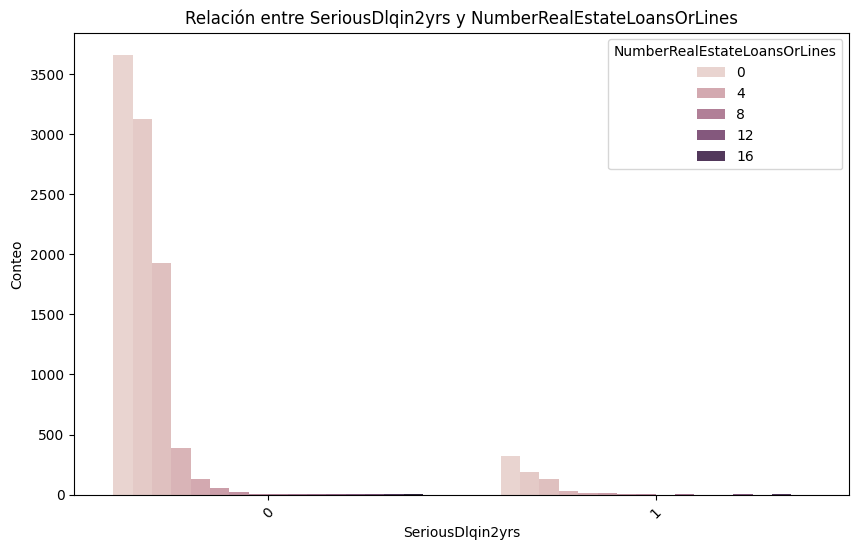

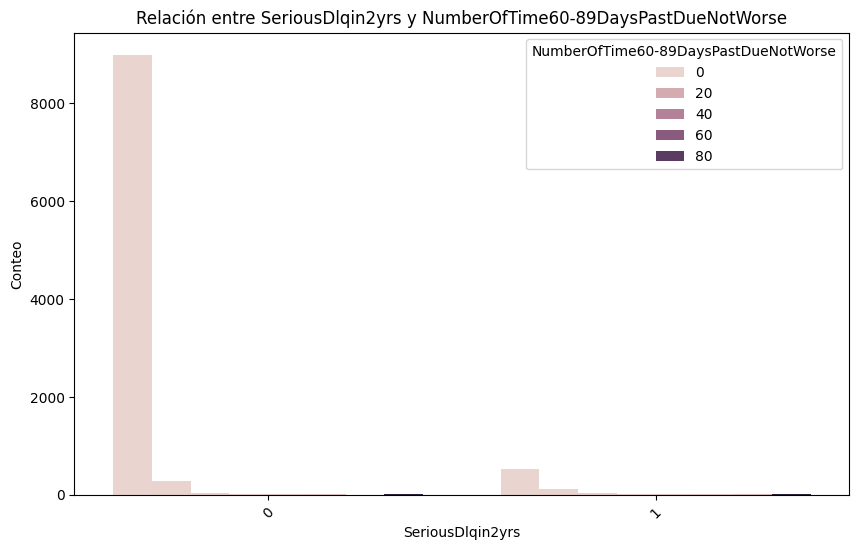

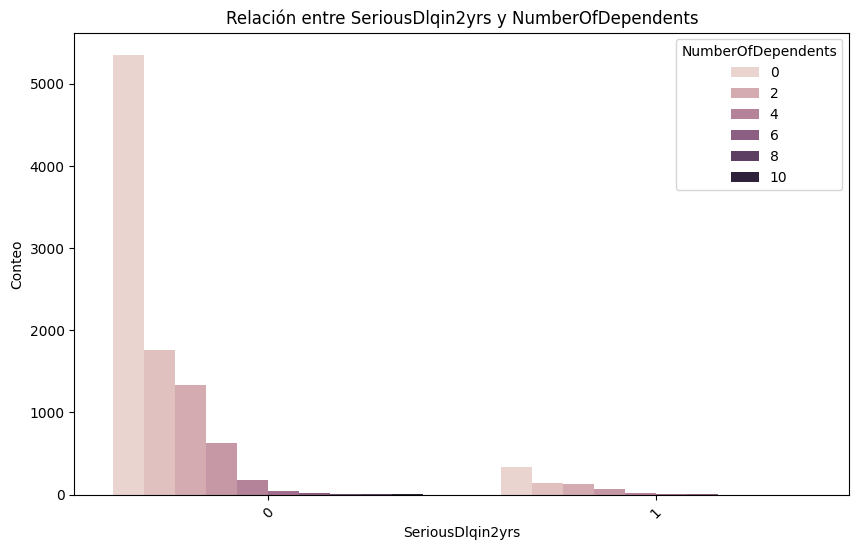

In [246]:
for categorica in categoricas:
    bt.plot_categorical_relationship_fin(df_train, target, categorica, size_group=len(categoricas))

In [247]:
df_train[numericas].columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
       'MonthlyIncome'],
      dtype='object')

In [248]:
df_train[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']]=df_train[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']].apply(lambda x: np.log(x+0.1))

df_train['MonthlyIncome'] = df_train['MonthlyIncome'].apply(lambda x: np.cbrt(x))


In [249]:
df_test[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']]=df_test[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']].apply(lambda x: np.log(x+0.1))

df_test['MonthlyIncome'] = df_test['MonthlyIncome'].apply(lambda x: np.cbrt(x))

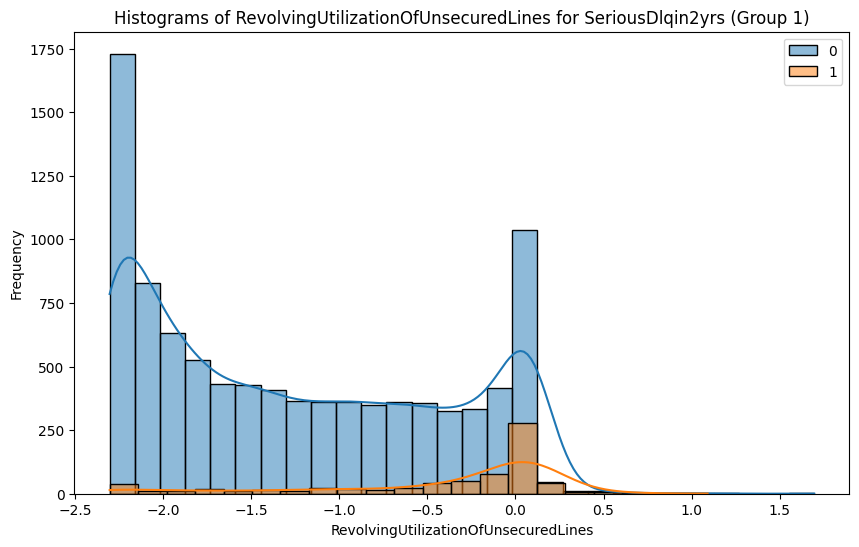

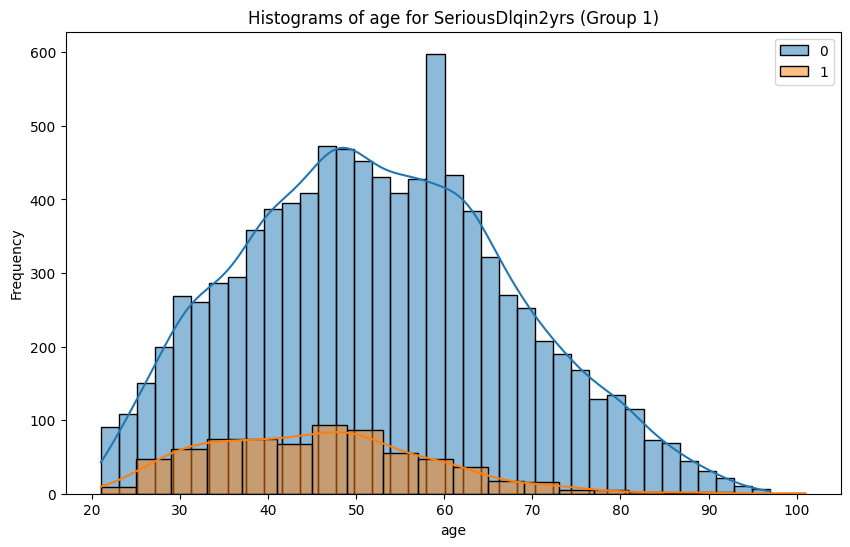

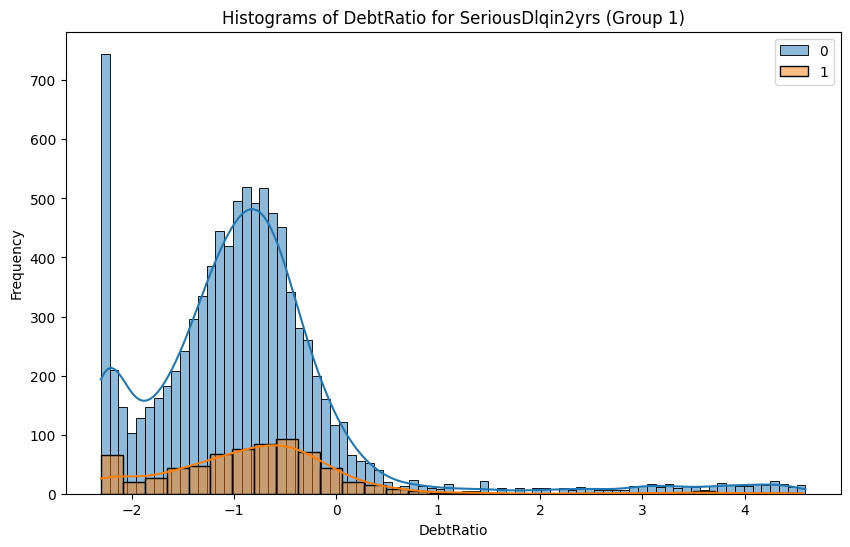

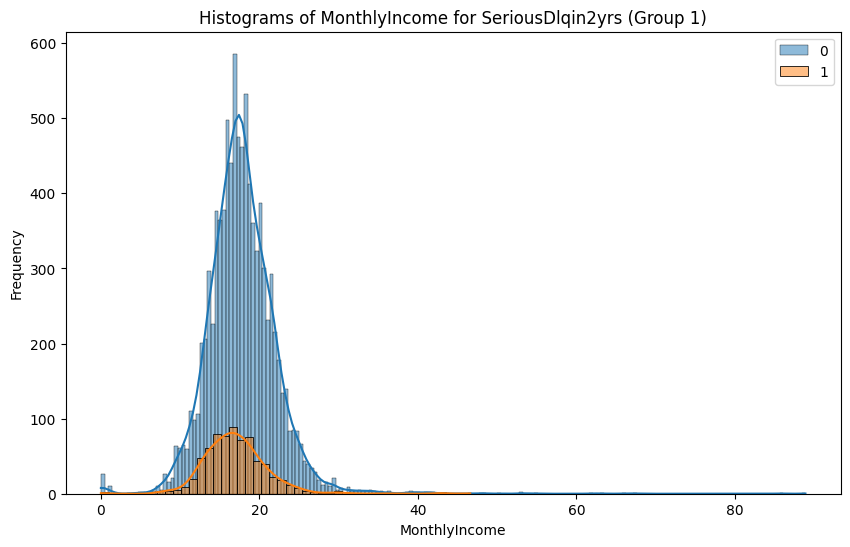

In [250]:
for numerica in numericas:
    bt.plot_grouped_histograms(df_train, target, numerica, len(numericas) )

In [251]:
numericas = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',"MonthlyIncome"]

In [252]:
categoricas = ['NumberOfTime30-59DaysPastDueNotWorse','NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents']
binarias = ["MonthlyIncome_binary","NumberOfDependents_binary"] 

In [253]:
from sklearn.preprocessing import StandardScaler

In [254]:
escalador = StandardScaler()

In [255]:
df_train[numericas] = pd.DataFrame(escalador.fit_transform(df_train[numericas]), columns=df_train[numericas].columns, index=df_train.index)

In [256]:
df_test[numericas] = pd.DataFrame(escalador.transform(df_test[numericas]), columns=df_train[numericas].columns,index=df_test.index)

In [257]:
df_train[numericas].describe()

,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome
count,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04
mean,1.133581e-17,1.519707e-16,4.321778e-17,-4.103917e-16
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-1.278135e+00,-2.058341e+00,-1.322575e+00,-4.000540e+00
25%,-9.664984e-01,-7.306653e-01,-5.213808e-01,-5.754132e-01
50%,-1.486772e-01,-6.682728e-02,-6.617121e-02,-5.747089e-02
75%,9.630139e-01,6.633945e-01,3.063316e-01,5.112682e-01
max,3.365471e+00,3.252363e+00,4.912700e+00,1.605354e+01


In [258]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10029 entries, 5441 to 7270
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      10029 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  10029 non-null  float64
 2   age                                   10029 non-null  float64
 3   NumberOfTime30-59DaysPastDueNotWorse  10029 non-null  int64  
 4   DebtRatio                             10029 non-null  float64
 5   MonthlyIncome                         10029 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       10029 non-null  int64  
 7   NumberOfTimes90DaysLate               10029 non-null  int64  
 8   NumberRealEstateLoansOrLines          10029 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  10029 non-null  int64  
 10  NumberOfDependents                    10029 non-null  float64
 11  MonthlyIncome_bina

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [259]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [260]:
x_train = df_train.drop(columns="SeriousDlqin2yrs")
x_test = df_test.drop(columns="SeriousDlqin2yrs")
y_train = df_train["SeriousDlqin2yrs"]
y_test=df_test["SeriousDlqin2yrs"]

In [261]:
balanceo_abajo = SMOTE( random_state=42)

In [262]:
x_train_resample, y_train_resample = balanceo_abajo.fit_resample(x_train,y_train)
x_test_resample, y_test_resample = balanceo_abajo.fit_resample(x_test,y_test)

In [263]:

xgbc = XGBClassifier(max_depth=10,n_estimators=300, random_state= 42 )
rfc = RandomForestClassifier(max_depth = 10, random_state= 42,n_estimators=300,n_jobs=-1)
knn = KNeighborsClassifier(n_neighbors=5)

In [264]:
from sklearn.model_selection import cross_val_score

In [265]:
np.mean(cross_val_score(xgbc, x_train_resample,y_train_resample,cv=5, scoring="balanced_accuracy"))

np.float64(0.9444700568088757)

In [266]:
np.mean(cross_val_score(rfc, x_train_resample,y_train_resample, scoring="balanced_accuracy"))

np.float64(0.8353874468763738)

In [267]:
np.mean(cross_val_score(knn, x_train_resample,y_train_resample,cv=5, scoring="balanced_accuracy"))

np.float64(0.8818616185213599)

In [279]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    "n_estimators": [100, 200, 300],          # número de árboles
    "max_depth": [3, 5, 7],                   # profundidad máxima
    "learning_rate": [0.01, 0.05, 0.1],      # tasa de aprendizaje
    "subsample": [0.7, 0.85, 1.0],           # muestreo de filas
    "colsample_bytree": [0.7, 0.85, 1.0],    # muestreo de columnas
    "gamma": [0, 0.1, 0.3],                   # regularización de nodo
    "reg_lambda": [1, 1.5, 2],                # regularización L2
    "scale_pos_weight": [scale_pos_weight]}

In [269]:
from sklearn.model_selection import GridSearchCV

In [280]:
grids = GridSearchCV(estimator = xgbc ,param_grid=param_grid, cv=5, n_jobs=-1, verbose=False, scoring="balanced_accuracy")


In [281]:
grids.fit(x_train_resample,y_train_resample)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.85, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [282]:
grids.best_score_

np.float64(0.9033017536902781)

In [283]:
grids.best_params_

{'colsample_bytree': 1.0,
 'gamma': 0.3,
 'learning_rate': 0.1,
 'max_depth': 7,
 'n_estimators': 300,
 'reg_lambda': 1,
 'scale_pos_weight': np.float64(13.306704707560627),
 'subsample': 0.7}

In [285]:
xgbc_f = XGBClassifier(**grids.best_params_)

In [286]:
xgbc_f.fit(x_train_resample,y_train_resample)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [287]:
print(classification_report(y_test,xgbc_f.predict(x_test)))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89      2345
           1       0.19      0.55      0.28       163

    accuracy                           0.81      2508
   macro avg       0.57      0.69      0.59      2508
weighted avg       0.91      0.81      0.85      2508



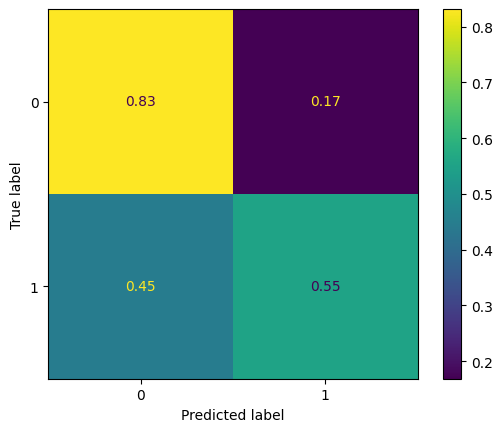

In [288]:
ConfusionMatrixDisplay.from_predictions(y_test, xgbc_f.predict(x_test), normalize="true")

In [ ]:
xgbc_f.feature_importances_

array([0.1317086 , 0.08577441, 0.09899929, 0.05542629, 0.05942008,
       0.07333574, 0.10309892, 0.07980744, 0.06448592, 0.1212753 ,
       0.02519343, 0.1014745 ], dtype=float32)

In [ ]:
xgbc_f.feature_names_in_

array(['RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
       'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
       'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents',
       'MonthlyIncome_binary', 'NumberOfDependents_binary'], dtype='<U36')

In [302]:
pd.DataFrame(xgbc_f.feature_importances_.T, index=[xgbc_f.feature_names_in_]).sort_values(by=0 ,ascending=False)

,0
RevolvingUtilizationOfUnsecuredLines,0.131709
NumberOfDependents,0.121275
NumberOfTimes90DaysLate,0.103099
NumberOfDependents_binary,0.101475
NumberOfTime30-59DaysPastDueNotWorse,0.098999
age,0.085774
NumberRealEstateLoansOrLines,0.079807
NumberOfOpenCreditLinesAndLoans,0.073336
NumberOfTime60-89DaysPastDueNotWorse,0.064486
MonthlyIncome,0.059420
